# Atlantic hurricanes: a shift in activity in the 1990s

Atlantic hurricane activity is not stationary. The Atlantic Multidecadal
Oscillation (AMO), a roughly 60–80-year swing in North Atlantic sea-surface
temperature, modulates it in long phases: an active phase ~1944–1969, a quiet
phase ~1970–1994, and a markedly more active phase since 1995. In a *Science*
paper, Goldenberg, Landsea, Mestas-Nuñez & Gray (2001) argued that
major-hurricane activity jumped after 1995 and would persist for decades. Here
we ask whether that transition can be detected and dated from the count data
alone, and how large it was, without telling the model when to look.

This is the kind of question *bayesloop* is built for. We put a Poisson
observation model on the annual storm counts, let the rate vary in time, and ask
the data which kind of variation it prefers, using the marginal likelihood
(model evidence) as an objective, complexity-penalised score. Along the way we
exercise a focused slice of the toolbox: the `Poisson` observation model;
`Study`, `HyperStudy` and `ChangepointStudy`; and the `Static`,
`GaussianRandomWalk` and `ChangePoint` transition models. The analysis mirrors a
stationary-rate analysis (for example global earthquakes), run with identical
machinery, but here the evidence comes down firmly on the side of a changing
rate.

In [1]:
%matplotlib inline
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import bayesloop as bl

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.edgecolor": "#444444", "grid.color": "#d9d9d9",
})
C = {"data": "#8a8a8a", "accent": "#c1272d", "accent2": "#0b6e99",
     "green": "#2e7d32", "amber": "#e8a33d", "muted": "#8a8a8a",
     "band": "#c1272d", "band2": "#0b6e99"}


def posterior_band(S, name, lo=0.05, hi=0.95):
    """Posterior mean and an equal-tailed credible band for a time-varying parameter."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mean = (p * x[None, :]).sum(axis=1)
    cdf = np.cumsum(p, axis=1)
    low = np.array([np.interp(lo, cdf[t], x) for t in range(p.shape[0])])
    high = np.array([np.interp(hi, cdf[t], x) for t in range(p.shape[0])])
    return mean, low, high


def prob_in(S, name, lo=None, hi=None):
    """Posterior probability the parameter lies in (lo, hi] at each time step."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mask = np.ones_like(x, dtype=bool)
    if lo is not None:
        mask &= x > lo
    if hi is not None:
        mask &= x <= hi
    return p[:, mask].sum(axis=1)

## The data

We use NOAA's HURDAT2 Atlantic hurricane best-track database, the canonical
record of every known Atlantic tropical cyclone since 1851, maintained by the
National Hurricane Center. It is a single plain-text file with a simple structure:
each storm starts with a *header line* (`AL{nn}{year}, NAME, n_records`), followed
by one *data line* per six-hour fix giving the storm's status and maximum
sustained wind in knots.

To get annual counts we stream the file once, track each storm's lifetime-maximum
wind, and bin storms into the standard intensity categories:

- named storms, peak wind ≥ 34 kt (tropical-storm strength or above),
- hurricanes, peak wind ≥ 64 kt,
- major hurricanes, peak wind ≥ 96 kt (Saffir–Simpson Category 3+).

Major hurricanes are the cleanest AMO indicator: they are both the least affected
by historical observational undercount and where the multidecadal signal is
strongest.

In [2]:
UA = "Mozilla/5.0 (bayesloop docs; research)"
HURDAT_URLS = [
    "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2023-051124.txt",
    "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2024-040425.txt",
    "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2022-050423.txt",
]
text = None
for url in HURDAT_URLS:
    try:
        req = urllib.request.Request(url, headers={"User-Agent": UA})
        text = urllib.request.urlopen(req, timeout=90).read().decode("utf-8", "replace")
        break
    except Exception:  # noqa: BLE001 — try the next mirror
        continue
if text is None:
    raise RuntimeError("Could not download HURDAT2 from any mirror.")


def parse_hurdat2(text):
    """Parse the raw HURDAT2 text into annual counts of named storms, hurricanes
    and major hurricanes (binned on each storm's lifetime-maximum wind in knots)."""
    rows, year, maxwind = [], None, -999

    def flush():
        if year is not None:
            rows.append((year, maxwind))

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        parts = [p.strip() for p in line.split(",")]
        if parts[0].startswith("AL") and len(parts[0]) == 8:
            # storm header line: close out the previous storm and start a new one
            flush()
            year = int(parts[0][4:8])
            maxwind = -999
        else:
            # track fix: field index 6 is the max sustained wind in knots
            try:
                w = int(parts[6])
            except (ValueError, IndexError):
                w = -999
            if w > maxwind:
                maxwind = w
    flush()

    df = pd.DataFrame(rows, columns=["year", "maxwind"])
    df = df[df["maxwind"] >= 0]
    return df.groupby("year").agg(
        named=("maxwind", lambda w: int((w >= 34).sum())),
        hurricanes=("maxwind", lambda w: int((w >= 64).sum())),
        major=("maxwind", lambda w: int((w >= 96).sum())),
    ).reset_index()


g = parse_hurdat2(text)

# The basin-wide record before the routine aircraft-reconnaissance era (1944-)
# undercounts storms that stayed at sea, so we analyse from 1944 onward and stop at
# the last complete season in this file.
g = g[g["year"] <= 2023]
print(f"HURDAT2 parsed: {int(g['year'].min())}-{int(g['year'].max())} "
      f"({len(g)} seasons); 2023 had {int(g[g['year']==2023]['hurricanes'].iloc[0])} "
      f"hurricanes, {int(g[g['year']==2023]['major'].iloc[0])} major.")

HURDAT2 parsed: 1851-2023 (173 seasons); 2023 had 7 hurricanes, 3 major.


## A time-varying rate over the aircraft era

Our observation model is a `Poisson` whose rate is allowed to drift from year to
year. We wrap it in a `HyperStudy` with a `GaussianRandomWalk` on the rate and
let bayesloop marginalise over the unknown step size `sigma`, so the amount of
smoothing is inferred rather than hand-tuned. We fit two series over the
aircraft-reconnaissance era (1944–2023): all hurricanes, and major hurricanes.

In [3]:
def fit_rate(series_years, series_counts, ratemax):
    S = bl.HyperStudy()
    S.load_data(series_counts.astype(float), timestamps=series_years.astype(float))
    S.set(bl.om.Poisson("rate", bl.oint(0, ratemax, 600)),
          bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 0.8, 40), target="rate"))
    S.fit(silent=True)
    return S


air = g[g["year"] >= 1944]
ay = air["year"].values
Smaj = fit_rate(ay, air["major"].values, 9.0)
maj_mean, maj_lo, maj_hi = posterior_band(Smaj, "rate")
Shur = fit_rate(ay, air["hurricanes"].values, 16.0)
hur_mean, hur_lo, hur_hi = posterior_band(Shur, "rate")

+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


Plotting the inferred rate against the AMO phases shows the signal clearly:
the major-hurricane rate sits high in the warm 1944–69 phase, sags through the
cool 1970–94 phase, and climbs sharply after 1995. The all-hurricane series shows
the same shape more weakly, as expected.

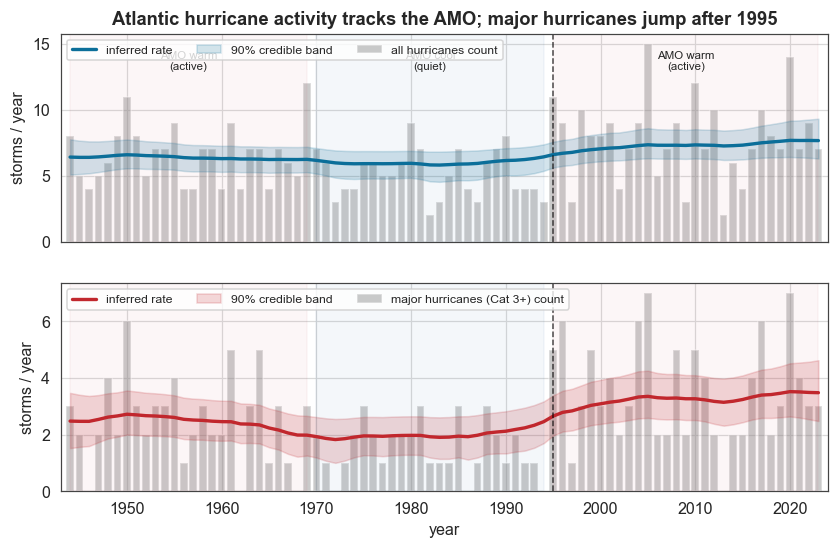

In [4]:
phases = [(1944, 1969, "AMO warm\n(active)"), (1970, 1994, "AMO cool\n(quiet)"),
          (1995, 2023, "AMO warm\n(active)")]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.4), sharex=True)
for ax, counts, mean, lo, hi, lab, col in [
    (ax1, air["hurricanes"].values, hur_mean, hur_lo, hur_hi, "all hurricanes", C["accent2"]),
    (ax2, air["major"].values, maj_mean, maj_lo, maj_hi, "major hurricanes (Cat 3+)", C["accent"]),
]:
    ax.bar(ay, counts, width=0.8, color=C["muted"], alpha=0.45, label=f"{lab} count")
    ax.plot(ay, mean, color=col, lw=2.2, label="inferred rate")
    ax.fill_between(ay, lo, hi, color=col, alpha=0.18, label="90% credible band")
    for x0, x1, _ in phases:
        ax.axvspan(x0, x1, color=("#cc6677" if x0 != 1970 else "#4477aa"), alpha=0.06)
    ax.axvline(1995, color="k", ls="--", lw=1, alpha=0.7)
    ax.set_ylabel("storms / year")
    ax.legend(loc="upper left", ncol=3, fontsize=8)
for x0, x1, txt in phases:
    ax1.text((x0 + x1) / 2, ax1.get_ylim()[1] * 0.92, txt, ha="center", va="top", fontsize=7.5)
ax1.set_title("Atlantic hurricane activity tracks the AMO; major hurricanes jump after 1995")
ax2.set_xlabel("year")
ax2.set_xlim(1943, 2024)
plt.show()

## Constant, gradual, or a single break?

The picture above assumes a smoothly drifting rate. We now test whether the data
prefer that over the alternatives by pitting three hypotheses against each other.
Every model shares the identical Poisson observation model and the same data
window, so their log₁₀ marginal likelihoods (`S.log10_evidence`) are directly
comparable.

| Model | Transition |
|---|---|
| Constant rate | `tm.Static()` |
| Gradually varying | `tm.GaussianRandomWalk` (HyperStudy over the step size) |
| Single change-point | `ChangepointStudy` + `tm.ChangePoint("t_change", "all")` |

We run the comparison on the homogeneous satellite era (1966–2023), where the
observing system is uniform and the evidence test is cleanest. The
`ChangepointStudy` scans every possible break year and returns a full posterior
over the date of the transition.

In [5]:
sat = g[g["year"] >= 1966]
sy = sat["year"].values.astype(float)
maj = sat["major"].values.astype(float)


def pois():
    return bl.om.Poisson("rate", bl.oint(0, 9, 600))


S0 = bl.Study(); S0.load_data(maj, timestamps=sy); S0.set(pois(), bl.tm.Static()); S0.fit(silent=True)
S2 = bl.HyperStudy(); S2.load_data(maj, timestamps=sy)
S2.set(pois(), bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 0.8, 40), target="rate")); S2.fit(silent=True)
Scp = bl.ChangepointStudy(); Scp.load_data(maj, timestamps=sy)
Scp.set(pois(), bl.tm.ChangePoint("t_change", "all")); Scp.fit(silent=True)
cp_x, cp_p = Scp.get_hyper_parameter_distribution("t_change")
cp_mode = float(cp_x[np.argmax(cp_p)])
order = np.argsort(cp_p)[::-1]; cum = np.cumsum(cp_p[order])
cred = np.sort(cp_x[order[:np.searchsorted(cum, 0.90) + 1]])

evid = {
    "Constant rate": float(S0.log10_evidence),
    "Gradually varying": float(S2.log10_evidence),
    "Single change-point": float(Scp.log10_evidence),
}

# Quantify the jump TWO ways, both on the satellite-era window the evidence/change-point use.
# (a) From the bayesloop posterior rate of the gradually-varying model (S2): mean inferred
#     rate in the quiet (pre-break) vs active (post-break) AMO phases, split at 1995.
# (b) As a model-independent cross-check, the raw annual-count means over the same phases.
r2_mean, _, _ = posterior_band(S2, "rate")
pre_inf = float(r2_mean[(sy >= 1966) & (sy <= 1994)].mean())
post_inf = float(r2_mean[(sy >= 1995) & (sy <= 2023)].mean())
pre = float(sat[(sat["year"] >= 1966) & (sat["year"] <= 1994)]["major"].mean())
post = float(sat[(sat["year"] >= 1995) & (sat["year"] <= 2023)]["major"].mean())

best = max(evid, key=evid.get)
print("Major-hurricane model evidence (satellite era 1966-2023, log10):")
for k, v in evid.items():
    print(f"  {k:22s} {v:8.2f}")
print(f"  best: {best}")
print(f"Change-point dated to {cp_mode:.0f} (90% credible {cred.min():.0f}-{cred.max():.0f})")
print(f"Major-hurricane rate (bayesloop posterior): quiet {pre_inf:.2f}/yr -> active {post_inf:.2f}/yr "
      f"({post_inf/pre_inf:.2f}x);  raw-count cross-check {pre:.2f} -> {post:.2f} ({post/pre:.2f}x)")

+ Created new study.
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


+ Created new study.
  --> Hyper-study
  --> Change-point analysis
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Change-point. Hyper-Parameter(s): ['t_change']
+ Detected 1 change-point(s) in transition model: ['t_change']
+ Set hyper-prior(s): ['uniform']
Major-hurricane model evidence (satellite era 1966-2023, log10):
  Constant rate            -49.28
  Gradually varying        -47.45
  Single change-point      -48.56
  best: Gradually varying
Change-point dated to 1994 (90% credible 1992-1997)
Major-hurricane rate (bayesloop posterior): quiet 1.88/yr -> active 3.28/yr (1.74x);  raw-count cross-check 1.55 -> 3.55 (2.29x)


The evidence favours a changing rate. A time-varying rate is about
10¹·⁸ ≈ 60× more probable than a constant one, the mirror image of what the same
tooling returns for a stationary process. The gradual random walk even edges out
the single abrupt break, consistent with AMO transitions being fairly rapid but
not instantaneous.

The `ChangepointStudy` also dates the break, to 1994, with a 90% credible
interval of 1992–1997, squarely on the 1995 transition identified by Goldenberg
et al. The magnitude is close to a doubling: the smoothed posterior rate rises
from ~1.9/yr to ~3.3/yr (×1.74), while the raw counts go from ~1.6/yr to ~3.6/yr
(×2.29), in line with the "~2.5×" quoted in the *Science* paper. The smooth model
is the more conservative of the two because the random walk spreads the rise
across the transition years rather than snapping at a single break; both are
consistent readings of the same shift.

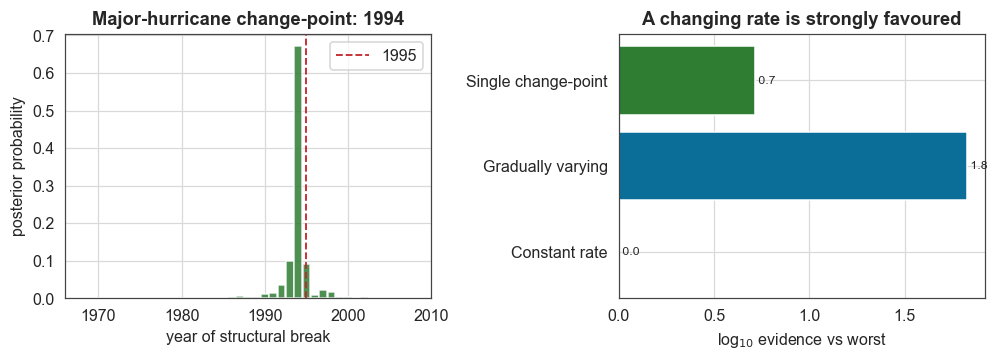

In [6]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9.2, 3.4))
axa.bar(cp_x, cp_p, width=0.9, color=C["green"], alpha=0.85)
axa.axvline(1995, color=C["accent"], ls="--", lw=1.2, label="1995")
axa.set_xlim(1966, 2010)
axa.set_xlabel("year of structural break")
axa.set_ylabel("posterior probability")
axa.set_title(f"Major-hurricane change-point: {cp_mode:.0f}")
axa.legend()
labels = list(evid.keys())
vals = np.array([evid[k] for k in labels]) - min(evid.values())
axb.barh(labels, vals, color=[C["muted"], C["accent2"], C["green"]])
axb.set_xlabel(r"log$_{10}$ evidence vs worst")
axb.set_title("A changing rate is strongly favoured")
for i, v in enumerate(vals):
    axb.text(v, i, f" {v:.1f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## What this example showed

On a single public dataset we used *bayesloop* to:

- answer a climatological question with model evidence: constant versus changing
  rate is settled quantitatively, and a time-varying rate wins by ~60×, the
  opposite of a stationary process analysed the same way;
- date a regime shift with a credible interval: the `ChangepointStudy` locates
  the AMO transition at 1994 (1992–1997) without being told when to look,
  independently confirming Goldenberg et al. (2001);
- quantify the jump: close to a doubling in the major-hurricane rate (×1.74 in
  the smoothed posterior, ×2.29 in raw counts), with the dependence on smoothing
  made explicit;
- exercise the core toolbox: the `Poisson` observation model with
  `Study`/`HyperStudy`/`ChangepointStudy` and the `Static`, `GaussianRandomWalk`
  and `ChangePoint` transition models, showing that restricting to the
  reliably-observed era is part of the analysis rather than an afterthought.